# Лабораторная работа №2

## Тема: **"Гармоники"**

---

**Работу выполнил:**  
Студент группы **5130901/20103**  
**Лучер Дмитрий Владимирович**

---

## Упражнение 2.1

В файле **chap02.ipynb** рассматриваются треугольный, прямоугольный и пилообразный сигналы, а также биения. Показано, как их генерировать, анализировать их спектры и прослушивать звучание.

## Упражнение 2.2

Скачаем библиотеку ThinkDSP из официального репозитория. Импортируем её, а также NumPy.

In [52]:
import os
if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
import thinkdsp
import numpy as np

Создаём класс **`SawtoothSignal`**, который расширяет базовый класс **`Signal`** и реализует метод **`evaluate`** для генерации пилообразного сигнала.

In [3]:
class SawtoothSignal(thinkdsp.Sinusoid):
    def evaluate(self, ts):
        cycles = self.freq * ts + self.offset / np.pi / 2
        frac, _ = np.modf(cycles)
        ys = thinkdsp.normalize(thinkdsp.unbias(frac), self.amp)
        return ys

Создадим экземпляр класса и вычислим его спектр. Также рассчитаем спектры соответствующих прямоугольного и треугольного сигналов.

In [21]:
sawtooth_spec = \
  SawtoothSignal().make_wave(duration=0.7, framerate=50000).make_spectrum()
square_spec = \
  thinkdsp.SquareSignal(amp=0.5).make_wave(duration=0.7, framerate=50000).make_spectrum()
triangle_spec = \
  thinkdsp.TriangleSignal(amp=0.8).make_wave(duration=0.7, framerate=50000).make_spectrum()

Сравним спектры пилообразного и прямоугольного сигналов.

Обратим внимание, что спектр пилообразного сигнала убывает аналогично, но содержит как чётные, так и нечётные гармоники, тогда как спектр прямоугольного сигнала включает только нечётные.


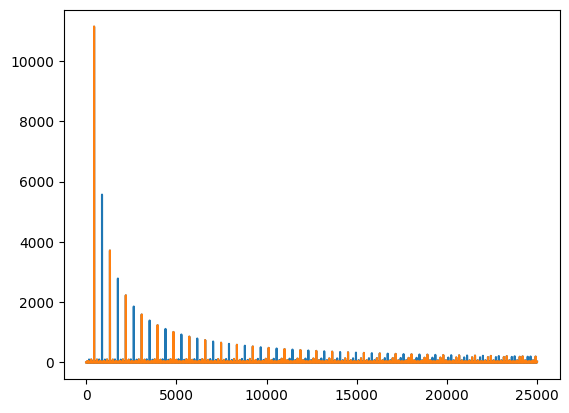

In [53]:
sawtooth_spec.plot()
square_spec.plot()

Теперь сравним спектры пилообразного и треугольного сигналов.

Спектр треугольного сигнала убывает значительно быстрее и также включает только нечётные гармоники.


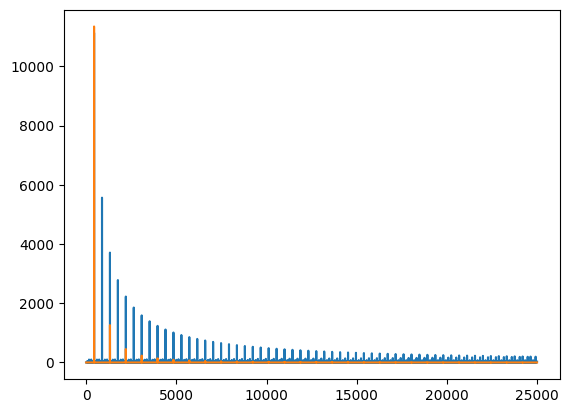

In [23]:
sawtooth_spec.plot()
triangle_spec.plot()

## Упражнение 2.3

Создадим прямоугольный сигнал с частотой 1100 Гц. На основе него создаим объект Wave с длительностью 0.7 секунд и выборками 10000 кадров в секунду.

In [54]:
square_signal: thinkdsp.SquareSignal = thinkdsp.SquareSignal(freq=1100)
square_wave: thinkdsp.Wave = square_signal.make_wave(duration=0.7, framerate=10000)

Построим спектр данного сигнала. Заметим, что из-за биений большинство гармоник "завернуты".

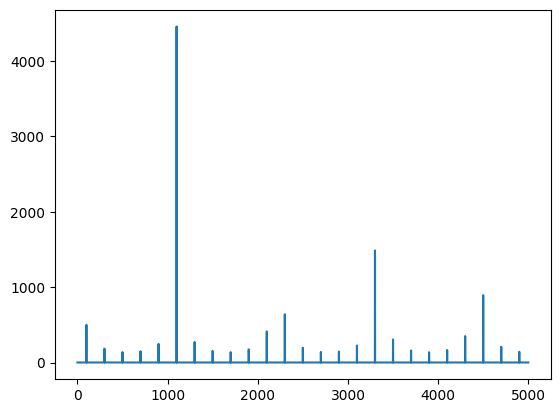

In [55]:
square_spectrum: thinkdsp.Spectrum = square_wave.make_spectrum()
square_spectrum.plot()

Прослушаем полученный сигнал в аудиоформате. Из-за возникновения биений получается гудящий, резкий звук.

In [34]:
square_wave.make_audio()

## Упражнение 2.4

Создадим треугольный сигнал с частотой 440 Гц и длительностью 0.01 секунд в формате wave.

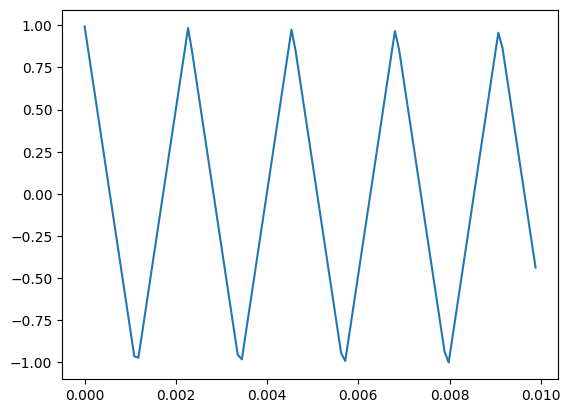

In [35]:
triangle_wave = thinkdsp.TriangleSignal(freq=440).make_wave(duration=0.01)
triangle_wave.plot()


На основе объекта **Wave** создадим спектр и выведем **`Spectrum.hs[0]`**. Полученное значение — комплексное число, где мнимая часть равна нулю, а действительная имеет очень малое значение порядка \(10^{-14}\).


In [56]:
triangle_spectrum = triangle_wave.make_spectrum()
triangle_spectrum.hs[0]

np.complex128(1.0436096431476471e-14+0j)

Изменим значение нулевой компоненты спектра на 100 и 200. Сравним графики сигналов (синий — до изменения, зелёный — после изменения на 100, красный — после изменения на 200). 

Обратите внимание, что график сдвинулся вверх на 1 и 2 единицы соответственно. Это подтверждает, что нулевая компонента спектра отвечает за вертикальный сдвиг волны.


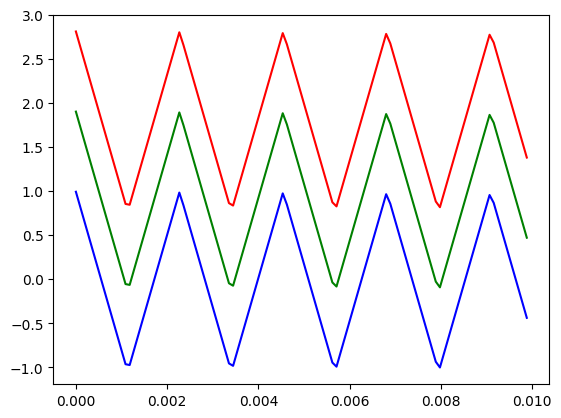

In [57]:
triangle_wave.plot(color='blue')

triangle_spectrum.hs[0] = 100
triangle_spectrum.make_wave().plot(color='green')

triangle_spectrum.hs[0] = 200
triangle_spectrum.make_wave().plot(color='red')

## Упражнение 2.5

Напишем функцию, которая принимает объект **`Spectrum`** в качестве аргумента и изменяет его, деля каждый элемент **`hs`** на соответствующую частоту из **`fs`**.

In [58]:
def alter_spectrum(s: thinkdsp.Spectrum):
  s.hs[0] = 0
  for i in range(1, len(s.hs)):
    s.hs[i] /= s.fs[i]

Проверим эту функцию на прямоугольном, треугольном и пилообразном сигналах.

## Прямоуголный сигнал

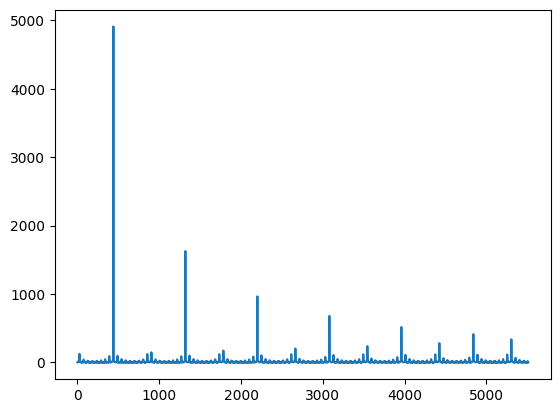

In [61]:
sq_wave = thinkdsp.SquareSignal().make_wave(duration=0.7)
sq_spectrum = sq_wave.make_spectrum()
sq_spectrum.plot()
sq_wave.make_audio()

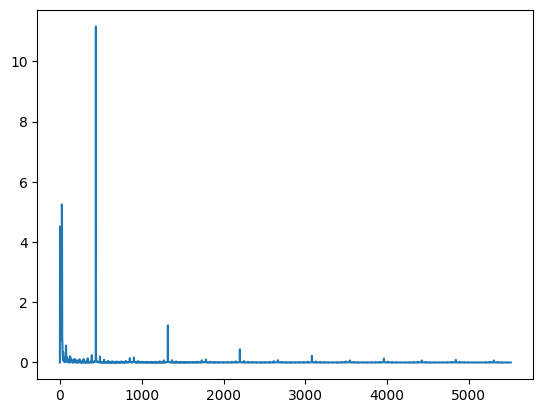

In [62]:
alter_spectrum(sq_spectrum)
sq_spectrum.plot()
sq_spectrum.make_wave().make_audio()

## Треуголный сигнал

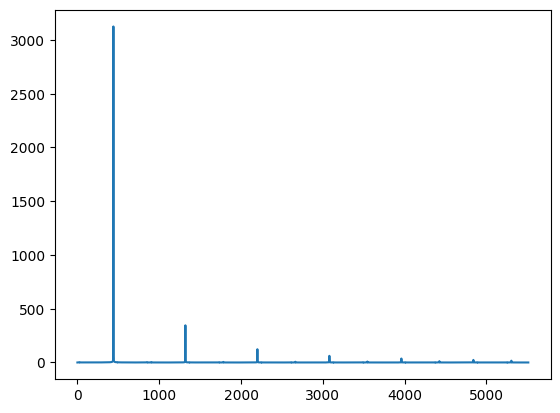

In [63]:
tr_wave = thinkdsp.TriangleSignal().make_wave(duration=0.7)
tr_spectrum = tr_wave.make_spectrum()
tr_spectrum.plot()
tr_wave.make_audio()

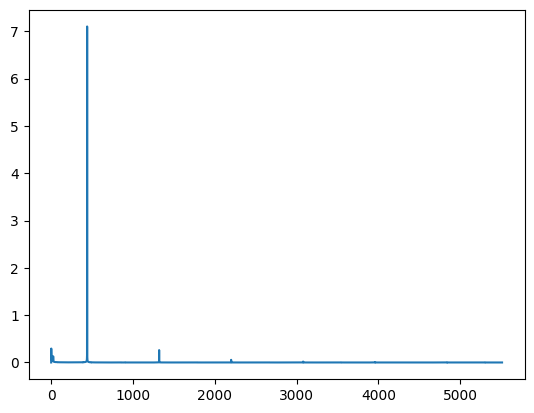

In [64]:
alter_spectrum(tr_spectrum)
tr_spectrum.plot()
tr_spectrum.make_wave().make_audio()

## Пилообразный сигнал

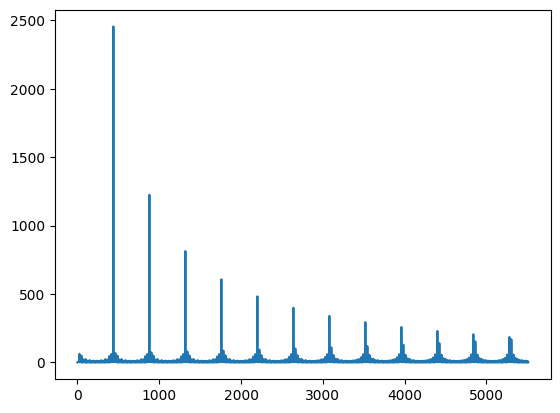

In [65]:
st_wave = thinkdsp.SawtoothSignal().make_wave(duration=0.7)
st_spectrum = st_wave.make_spectrum()
st_spectrum.plot()
st_wave.make_audio()

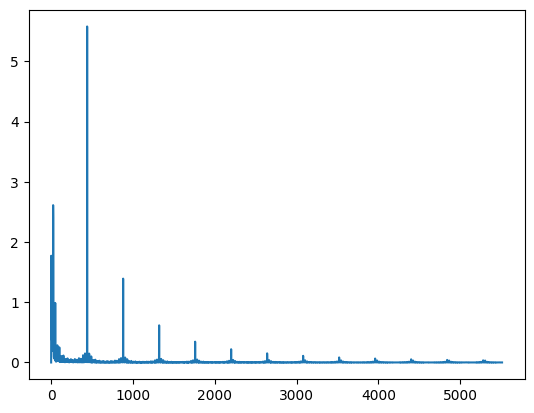

In [66]:
alter_spectrum(st_spectrum)
st_spectrum.plot()
st_spectrum.make_wave().make_audio()

Полученная функция преобразует входной сигнал таким образом, что его звучание становится более похожим на синусоидальный сигнал.

## Упражнение 2.6

Чтобы получить сигнал, содержащий и чётные, и нечётные гармоники, а также спадающий пропорционально $$\frac{1}{f^2}$$, воспользуемся пилообразным сигналом. 
Он уже имеет необходимые гармоники, но спадает пропорционально $$\frac{1}{f}$$. Это можно изменить, применив созданную ранее функцию **`alter_spectrum()`**.



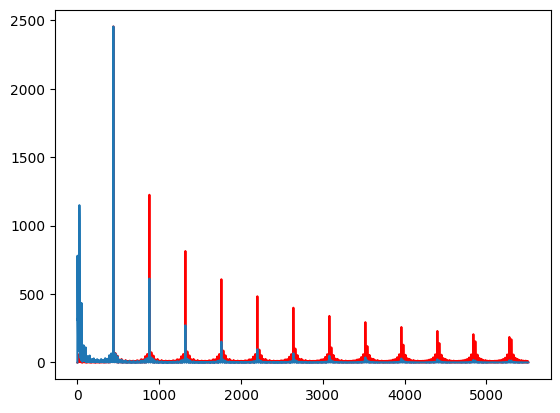

In [67]:
st = thinkdsp.SawtoothSignal(freq=440).make_wave(duration=0.7).make_spectrum()
st.plot(color='red')
alter_spectrum(st)
st.scale(440)
st.plot()